[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlosfab/bootcamp-visao-computacional-drones/blob/main/aula-02/04-treinamento-inferencia.ipynb)

Vamos construir e treinar uma CNN pequena para **classificar imagens**.
Começaremos pela estrutura de uma rede de referência, construiremos uma nova
instância e acompanharemos a atualização dos pesos. Ao final, faremos uma
inferência e calcularemos a acurácia no conjunto de teste.

A prática usa Fashion-MNIST e pode ser executada em CPU. Execute a preparação
e siga as células em ordem; este notebook funciona de forma independente.

In [1]:
from urllib.request import urlretrieve
base = "https://raw.githubusercontent.com/carlosfab/bootcamp-visao-computacional-drones/9a07beac812c2ca54116df0f41f44bc1020dddc8/"
urlretrieve(base + "apoio/aula02_treino.py", "apoio_treino.py");
urlretrieve(base + "dados/aula-02/cnn-classificacao.png", "cnn-classificacao.png");

In [2]:
import torch
from torch import nn
from PIL import Image

In [3]:
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import FashionMNIST
from torchvision.transforms import v2

In [4]:
import apoio_treino as apoio
apoio.preparar_dados()

**Como é a estrutura de uma rede simples?**

O auxiliar fornece uma CNN já montada para inspeção. Seus pesos são aleatórios:
**arquitetura pronta não significa rede treinada**. Não carregaremos pesos de um
modelo pré-treinado nesta prática.

O próprio PyTorch mostra a sequência de camadas quando imprimimos a rede.

In [5]:
referencia = apoio.rede_exemplo()
print(referencia)

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=1568, out_features=10, bias=True)
)


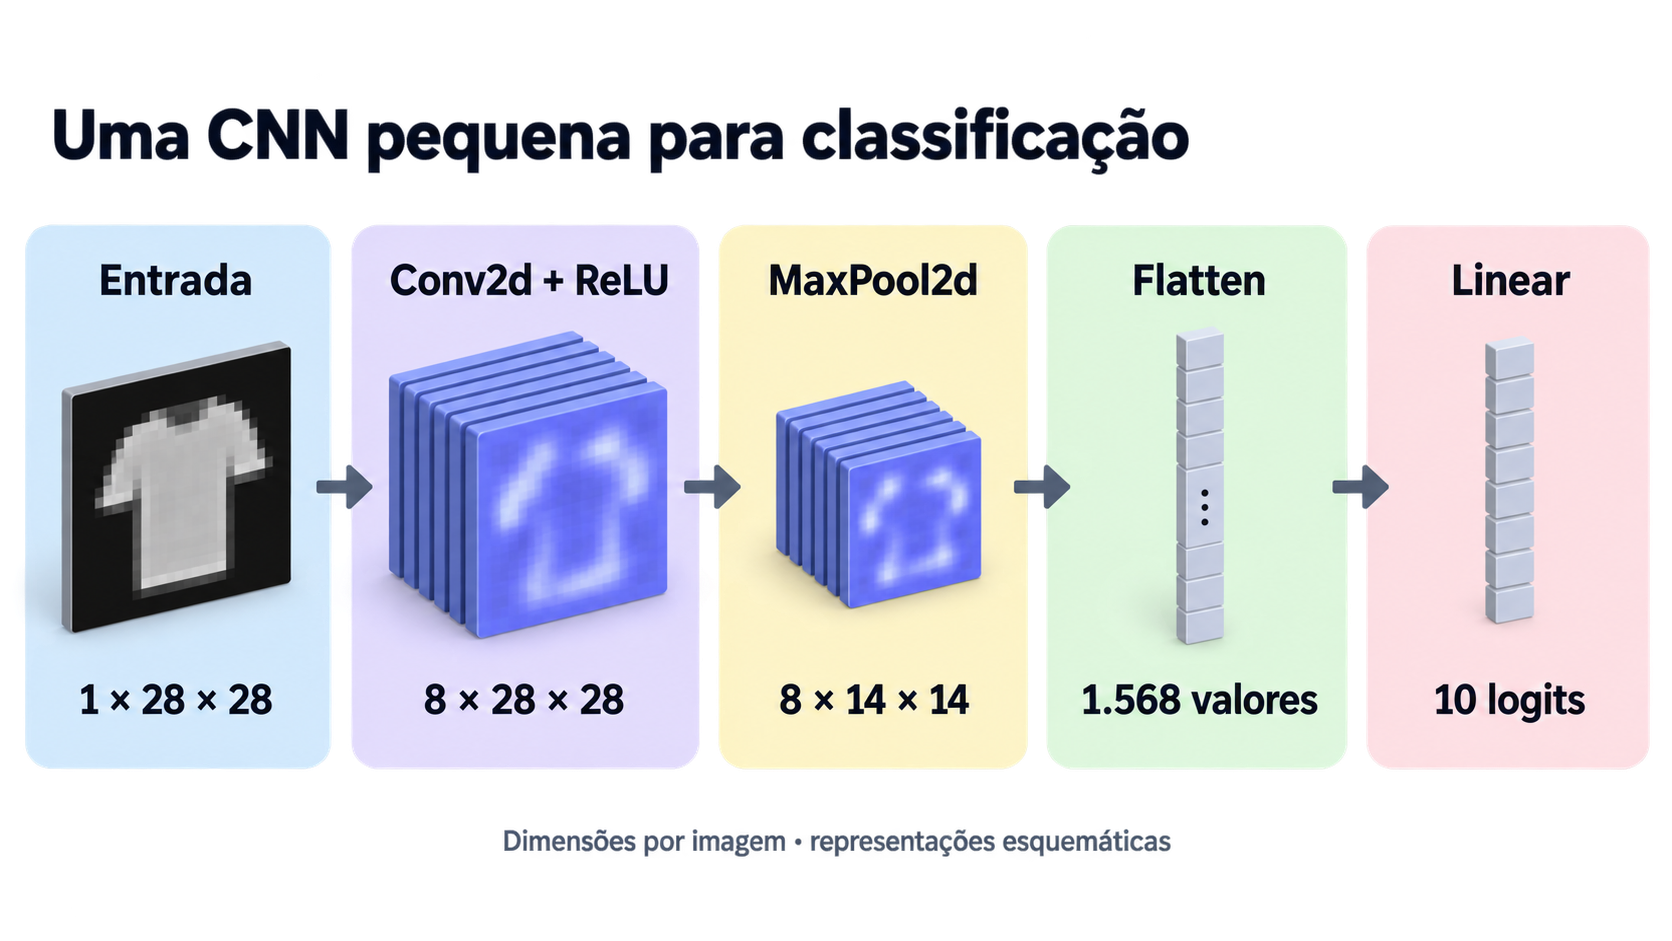

In [6]:
Image.open("cnn-classificacao.png")

A figura representa a arquitetura de forma esquemática. As dimensões estão
na ordem **canais, altura e largura**, sem o eixo do lote.
As texturas ilustram mapas; não são ativações medidas de uma rede treinada.

Vamos conferir as saídas e a quantidade de parâmetros de cada camada. O auxiliar
usa uma entrada de formato `[1, 1, 28, 28]` em uma cópia da rede.

In [7]:
apoio.resumo(referencia)

Camada,Configuração,Saída (N = 1),Parâmetros
Entrada,Imagem em escala de cinza,"(1, 1, 28, 28)",—
0 · Conv2d,"1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)","(1, 8, 28, 28)",80
1 · ReLU,,"(1, 8, 28, 28)",0
2 · MaxPool2d,"kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False","(1, 8, 14, 14)",0
3 · Flatten,"start_dim=1, end_dim=-1","(1, 1568)",0
4 · Linear,"in_features=1568, out_features=10, bias=True","(1, 10)",15.690
Total,,,15.770


A convolução tem oito filtros e preserva a resolução com `padding=1`.
A ReLU mantém o formato; o pooling reduz altura e largura à metade.
`Flatten` reorganiza os `8 × 14 × 14 = 1.568` valores de cada imagem.
`Linear` produz dez números, um por classe.

A rede tem **15.770 parâmetros**, incluindo os termos de bias.
ReLU, pooling e Flatten não têm parâmetros para aprender.
Os oito canais da convolução não representam as dez classes.

**Como construímos nossa própria rede?**

Vamos criar camadas novas pela API `nn`, com a mesma arquitetura da referência.
A semente permite repetir a inicialização no mesmo ambiente.

In [8]:
torch.manual_seed(42);

In [9]:
conv = nn.Conv2d(1, 8, 3, padding=1)
relu = nn.ReLU()
pool = nn.MaxPool2d(2)

In [10]:
flatten = nn.Flatten()
linear = nn.Linear(8 * 14 * 14, 10)

In [11]:
modelo = nn.Sequential(conv, relu, pool, flatten, linear)
print(modelo)

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=1568, out_features=10, bias=True)
)


`nn.Sequential` passa a saída de cada camada para a seguinte.
Criar a estrutura também inicializa os parâmetros, mas ainda precisamos
ajustá-los usando imagens e rótulos conhecidos.

**Quais dados usaremos para aprender?**

Fashion-MNIST contém imagens de roupas e acessórios: um canal, 28 × 28 pixels
e dez classes. A divisão oficial contém 60.000 imagens de treino e 10.000 de teste.

A preparação baixa os arquivos do repositório oficial por HTTPS.
A transformação abaixo converte a imagem em tensor com valores em `[0, 1]`.

In [12]:
transformar = v2.Compose([
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True)
])

In [13]:
treino = FashionMNIST("dados", train=True, transform=transformar)
teste = FashionMNIST("dados", train=False, transform=transformar)
len(treino), len(teste)

(60000, 10000)

In [14]:
classes = treino.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

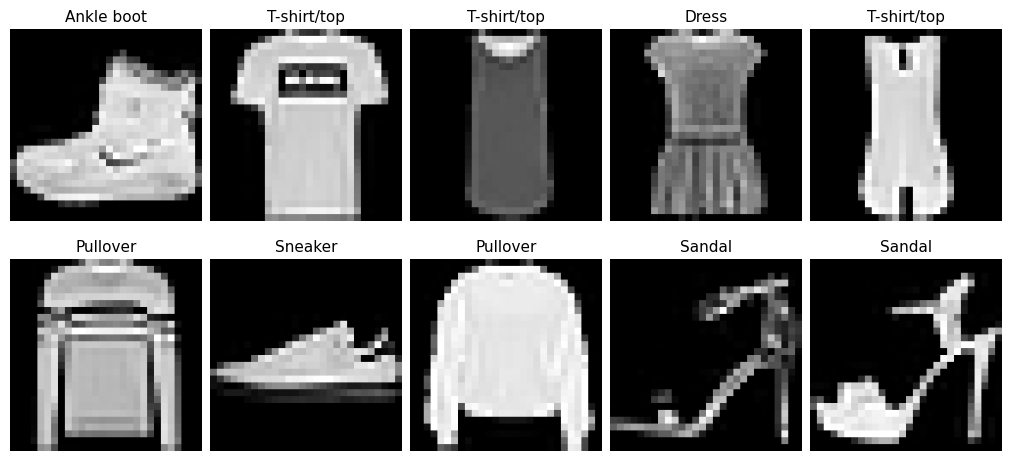

In [15]:
apoio.amostras(treino, classes)

Os nomes das classes seguem a ordem definida pelo dataset.
Cada exemplo traz uma imagem e um identificador inteiro entre 0 e 9.

Para manter o treinamento curto, selecionaremos **12.000 imagens do conjunto de
treino**. As demais imagens de treino ficarão sem uso nesta prática.
O conjunto de teste permanece separado e não participará das atualizações.

In [16]:
gerador = torch.Generator().manual_seed(42)
indices = torch.randperm(len(treino), generator=gerador)[:12000]
treino_curto = Subset(treino, indices)

Um `DataLoader` organiza os exemplos em lotes. Usaremos até 128 imagens
por atualização e embaralharemos sua ordem no treinamento.
No teste, basta percorrer os exemplos em ordem.

In [17]:
lotes_treino = DataLoader(treino_curto, batch_size=128, shuffle=True)
lotes_teste = DataLoader(teste, batch_size=256)

In [18]:
imagens, rotulos = next(iter(lotes_treino))
imagens.shape, rotulos.shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

As imagens têm formato `[N, C, H, W]`; os rótulos, `[N]`.
Cada uma das 128 imagens possui um rótulo. A rede produzirá dez números para
cada imagem: saída `[128, 10]`.

**O que acontece em uma atualização dos pesos?**

A função de perda compara a saída da rede com os rótulos conhecidos.
O otimizador usa os gradientes dessa perda para atualizar os parâmetros.
Vamos acompanhar uma atualização, uma operação por célula.

In [19]:
criterio = nn.CrossEntropyLoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

In [20]:
modelo.train()
otimizador.zero_grad()
logits = modelo(imagens)

In [21]:
logits.shape

torch.Size([128, 10])

Esses dez números são **logits**, não probabilidades.
`CrossEntropyLoss` recebe os logits diretamente e os rótulos inteiros.
Não devemos aplicar softmax antes dessa função de perda.

`zero_grad()` limpa os gradientes da atualização anterior. Na primeira
atualização, ainda não há gradientes acumulados.

In [22]:
perda = criterio(logits, rotulos)
perda.item()

2.311415672302246

`backward()` calcula os gradientes dos parâmetros que contribuíram para
a perda. A expressão seguinte apenas permite observar que há gradientes nos
pesos da convolução; ela não é uma métrica de avaliação.

In [23]:
perda.backward()
conv.weight.grad.abs().mean().item()

0.009348247200250626

Agora aplicaremos a atualização. Guardaremos uma cópia dos pesos da
convolução para conferir se seus valores mudaram.

In [24]:
antes = conv.weight.detach().clone()
otimizador.step()
torch.equal(antes, conv.weight)

False

O resultado `False` indica que os pesos comparados já não são idênticos.
A primeira atualização foi realizada.

**Como repetimos isso ao longo dos dados?**

Uma época é uma passagem pelos exemplos de treino selecionados.
A função abaixo reúne as mesmas operações. Ela também soma a perda ponderada
pelo tamanho de cada lote, para retornar a média por imagem.
Este bloco fica em uma única célula porque contém um laço completo.

In [25]:
def treinar_epoca():
    modelo.train()
    total = 0.
    for imagens, rotulos in lotes_treino:
        otimizador.zero_grad()
        perda = criterio(modelo(imagens), rotulos)
        perda.backward()
        otimizador.step()
        total += perda.item() * len(rotulos)
    return total / len(treino_curto)

Continuaremos a partir da atualização já feita e percorreremos as 12.000
imagens por três épocas. A perda mostrada é a média observada durante cada
passagem pelos lotes de treino.

In [26]:
perdas = []

In [27]:
for epoca in range(3):
    perdas.append(treinar_epoca())
    print(f"Época {epoca + 1}: perda = {perdas[-1]:.3f}")

Época 1: perda = 1.113


Época 2: perda = 0.635


Época 3: perda = 0.555


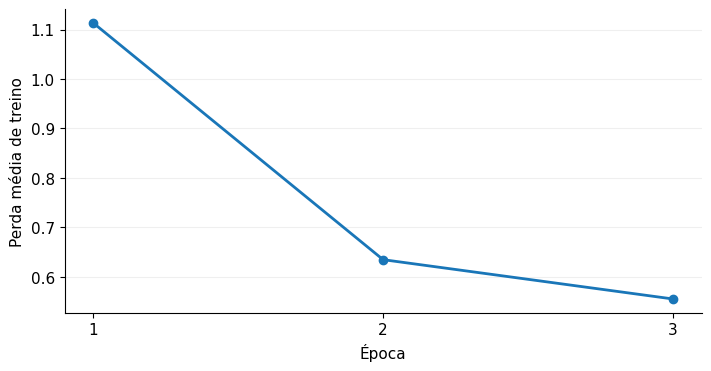

In [28]:
apoio.curva(perdas)

A redução da perda indica melhor ajuste aos exemplos de treino.
Ela não substitui a avaliação em imagens que não participaram das atualizações.

Reexecutar o treinamento continua ajustando os pesos atuais. Para recomeçar,
recrie a rede e o otimizador e execute as células seguintes em ordem.

**Como fazemos uma inferência?**

Vamos escolher uma imagem do conjunto de teste, que não foi usada nas atualizações.
O auxiliar amplia apenas a visualização; o tensor continua com 28 × 28 pixels.

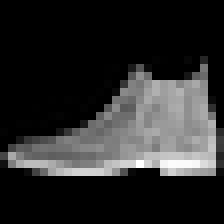

In [29]:
indice = 0
imagem, esperado = teste[indice]
apoio.mostrar(imagem)

In [30]:
modelo.eval()
with torch.inference_mode():
    logits = modelo(imagem.unsqueeze(0))

`unsqueeze(0)` acrescenta o eixo do lote: uma imagem vira uma entrada
`[1, 1, 28, 28]`. A saída contém uma linha com dez logits.

`eval()` coloca a rede no modo de avaliação. `inference_mode()` dispensa
o registro dos gradientes. Aqui não calculamos perda nem atualizamos pesos.

In [31]:
logits.shape, logits.round(decimals=2)

(torch.Size([1, 10]),
 tensor([[-5.8500, -5.5000, -4.3900, -4.7700, -3.9700,  2.9800, -3.7900,  3.5700,
           0.6800,  4.1000]]))

A classe prevista é o índice do maior logit. Vamos compará-la ao rótulo
fornecido pelo dataset.

In [32]:
previsto = logits.argmax(1).item()
classes[previsto], classes[esperado]

('Ankle boot', 'Ankle boot')

**Como avaliamos de forma simples?**

Uma previsão isolada não resume o desempenho. Vamos contar os acertos nas
10.000 imagens de teste e dividir pelo total: essa proporção é a **acurácia**.

A rede permanece em modo de avaliação, e o teste não calcula gradientes.

In [33]:
acertos = 0

In [34]:
with torch.inference_mode():
    for imagens, rotulos in lotes_teste:
        previstos = modelo(imagens).argmax(1)
        acertos += (previstos == rotulos).sum().item()

In [35]:
acuracia = acertos / len(teste)
print(f"Acurácia no teste: {acuracia:.1%}")

Acurácia no teste: 80.6%


A acurácia descreve este modelo no teste do Fashion-MNIST.
Escolhemos o número de épocas antes de observar esse resultado.
Para comparar configurações, separaríamos também um conjunto de validação.

Escolha outro índice de teste e repita somente a inferência.
A arquitetura permanece a mesma; os pesos ajustados no treinamento são reutilizados.

Na detecção de objetos, o treinamento também precisa aprender localizações.
Essa etapa será trabalhada no projeto, com dados e anotações apropriados.

Referências para consulta:

- [Fashion-MNIST: dataset e classes oficiais](https://github.com/zalandoresearch/fashion-mnist)
- [TorchVision: FashionMNIST](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html)
- [TorchVision: transformações v2](https://docs.pytorch.org/vision/stable/transforms.html)
- [PyTorch: construção de redes com nn](https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html)
- [PyTorch: laço de treinamento, perda e otimizador](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html)
- [PyTorch: CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

As imagens de roupas pertencem ao Fashion-MNIST. A figura da arquitetura é uma
ilustração esquemática gerada por IA para esta aula.